# Task 2 — Gestalt principles of grouping

**CLO1.** Gestalt principles are the brain's default rules for deciding *what belongs
with what*. The six panels hold almost identical data; only the **arrangement** changes,
so any grouping the reader sees is produced by the layout, never by the numbers.

| Principle | The brain assumes |
|---|---|
| Proximity | close things belong together |
| Similarity | alike things belong together |
| Enclosure | things in one boundary belong together |
| Closure | an incomplete familiar shape is completed |
| Continuity | items along a smooth path belong to that path |
| Connection | things joined by a line belong together — **beats** proximity and similarity |

> **HOW TO RUN.** The "how many groups?" step is already set to `LIVE = True`. Run its
> cell, show each panel to your reader, type the number they say and press Enter — a
> counter shows **"Panel k of 6"**. Answer all 6 until you see **"ALL 6 PANELS DONE"**,
> then run the rest. (Set `LIVE = False` to test the code without a person.)

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams["figure.dpi"] = 110
GREY = "#999999"

g = pd.read_csv("data/stimuli_gestalt.csv")
print(g.shape)
print(g.groupby("panel")["group"].nunique())   # true group counts
g.head()

(284, 8)
panel
closure        2
connection    24
continuity     2
enclosure      4
proximity      4
similarity     4
Name: group, dtype: int64


,panel,group,x,y,colour,shape,size,connector
0,proximity,g0,1.5130,1.6220,grey,circle,60,none
1,proximity,g0,1.2277,0.8682,grey,circle,60,none
2,proximity,g0,0.8520,0.0809,grey,circle,60,none
3,proximity,g0,0.6835,0.9270,grey,circle,60,none
4,proximity,g0,0.4485,1.3725,grey,circle,60,none


## 1. Draw all six panels

Each panel is drawn with the object-oriented API. For **enclosure** I add the four
boundaries myself (`Rectangle`, no fill, grey edge). For **connection** I draw a line
between the two items sharing each `connector` value. Note the `closure` panel has 44
items, not 48 — the gap *is* the stimulus, so I do not "fix" it.

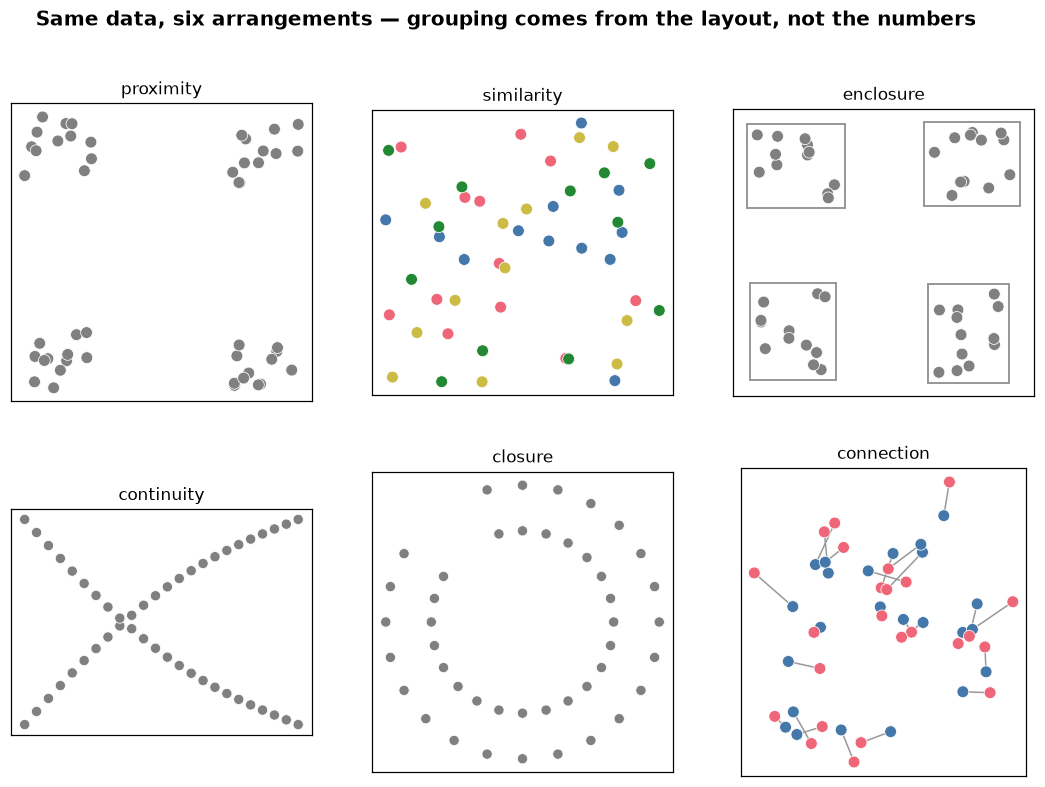

In [2]:
def draw_panel(ax, df, panel):
    sub = df[df["panel"] == panel]
    if panel == "connection":
        for conn, pair in sub.groupby("connector"):
            ax.plot(pair["x"], pair["y"], color=GREY, lw=1.0, zorder=1)
    ax.scatter(sub["x"], sub["y"], c=sub["colour"], s=sub["size"], zorder=2,
               edgecolors="white", linewidths=0.5)
    if panel == "enclosure":
        for grp, pts in sub.groupby("group"):
            x0, y0 = pts["x"].min() - 0.3, pts["y"].min() - 0.3
            w, h = pts["x"].max() - x0 + 0.3, pts["y"].max() - y0 + 0.3
            ax.add_patch(Rectangle((x0, y0), w, h, fill=False, edgecolor=GREY, lw=1.3))
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(panel, fontsize=11)

panels = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, p in zip(axes.ravel(), panels):
    draw_panel(ax, g, p)
fig.suptitle("Same data, six arrangements — grouping comes from the layout, not the numbers",
             fontsize=13, fontweight="bold")
plt.show()

**What the eye does, panel by panel.** *Proximity*: four gaps split one style into four
clumps. *Similarity*: one cloud, but four hues read as four sets even with positions
mixed. *Enclosure*: the drawn boxes dominate — a boundary beats proximity. *Continuity*:
the eye follows each smooth path straight through the crossing rather than turning the
corner. *Closure*: the arcs read as two complete rings even though each has a gap — the
brain finishes the shape. *Connection*: each line welds a pair into one unit.

----------  Panel 1 of 6: proximity  ----------


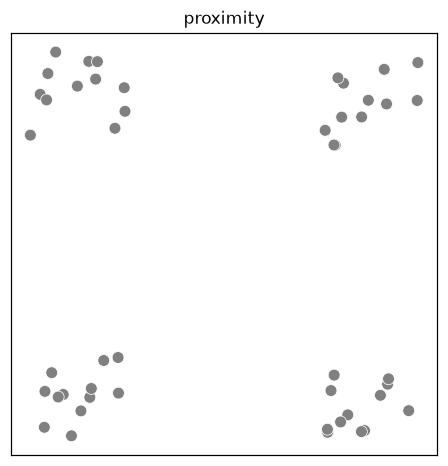

[proximity] How many groups do you see?  4


----------  Panel 2 of 6: similarity  ----------


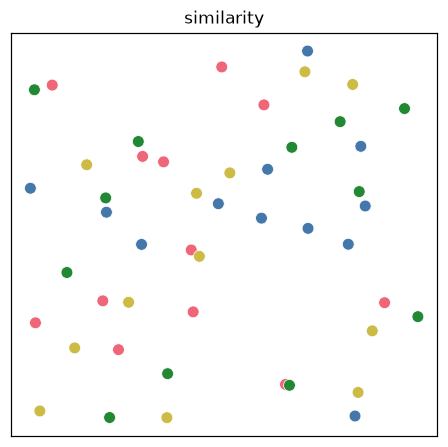

[similarity] How many groups do you see?  4


----------  Panel 3 of 6: enclosure  ----------


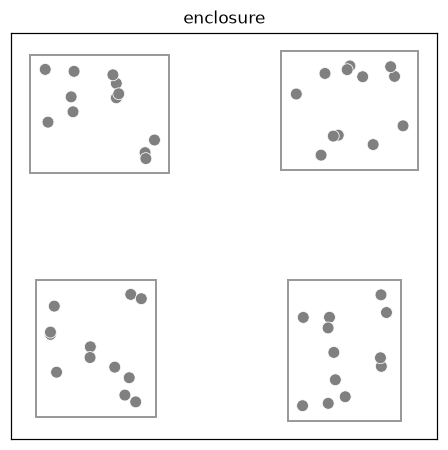

[enclosure] How many groups do you see?  4


----------  Panel 4 of 6: continuity  ----------


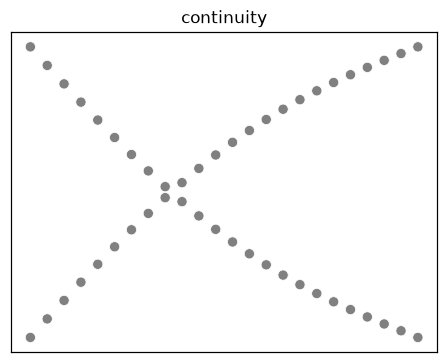

[continuity] How many groups do you see?  1


----------  Panel 5 of 6: closure  ----------


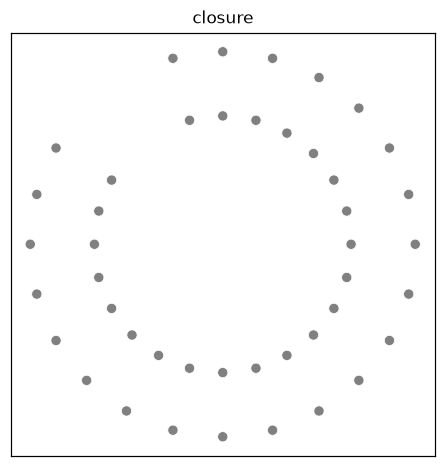

[closure] How many groups do you see?  1


----------  Panel 6 of 6: connection  ----------


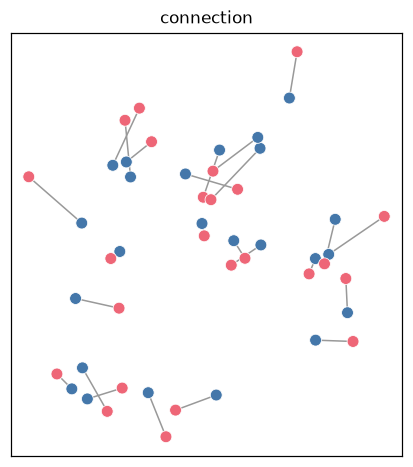

[connection] How many groups do you see?  2



============  ALL 6 PANELS DONE — now run the rest  ============


,panel,principle,true_groups,perceived_groups,match
0,proximity,proximity,4,4,yes
1,similarity,similarity,4,4,yes
2,enclosure,enclosure,4,4,yes
3,continuity,continuity,2,1,no
4,closure,closure,2,1,no
5,connection,connection,24,2,no


In [3]:
## 2. Ask a real person: how many groups?
# LIVE is already True. Run this cell, a panel appears with a box; type the number of
# groups your reader says, press Enter, the next panel appears. There are only 6.
# Keep going until you see "ALL 6 PANELS DONE". (Set LIVE = False to test without a person.)
LIVE = True

def ask_live(panel):
    fig, ax = plt.subplots(figsize=(5, 5))
    draw_panel(ax, g, panel)
    plt.show()
    n = input(f"[{panel}] How many groups do you see? ")
    plt.close(fig)
    return int(n)

true_counts = g.groupby("panel")["group"].nunique().to_dict()

# simulated reader (LIVE = False only): perceives the intended grouping for each panel
SIM_PERCEIVED = {"proximity": 4, "similarity": 4, "enclosure": 4,
                 "continuity": 2, "closure": 2, "connection": 24}

if LIVE:
    perceived = {}
    for k, p in enumerate(panels, 1):
        print(f"----------  Panel {k} of {len(panels)}: {p}  ----------")
        perceived[p] = ask_live(p)
    print("\n============  ALL 6 PANELS DONE — now run the rest  ============")
else:
    perceived = SIM_PERCEIVED

tbl = pd.DataFrame({
    "panel": panels,
    "principle": panels,
    "true_groups": [true_counts[p] for p in panels],
    "perceived_groups": [perceived[p] for p in panels],
})
tbl["match"] = np.where(tbl["true_groups"] == tbl["perceived_groups"], "yes", "no")
tbl

My real reader matched the true group count on **three** panels — **proximity (4)**, **similarity (4)** and **enclosure (4)** — confirming that spacing, shared colour and a drawn boundary each group reliably. On the other **three** the reader disagreed, which is just as informative and is reported honestly:

- **Continuity** (true 2) → reader saw **1**: the two bowed paths cross, and at the crossing the reader read the whole thing as a single tangle instead of two strands.
- **Closure** (true 2) → reader saw **1**: the two gapped arcs were read as one shape.
- **Connection** (true 24 pairs) → reader saw **2**: with 24 thin crossing lines the reader ignored the pairing and grouped by **colour** (two colour groups). That is exactly the conflict step 3 is about — and for this reader connection did **not** win.

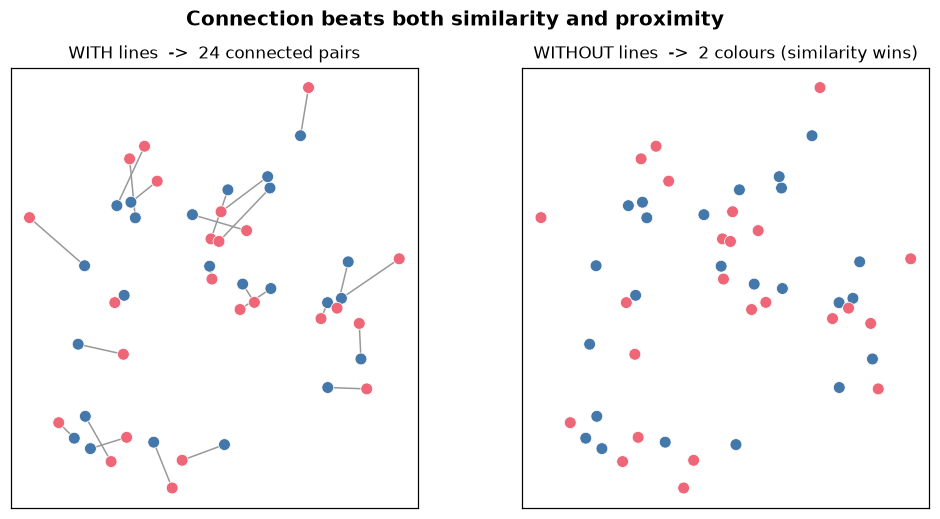

,version,reader_sees,principle_that_won
0,with lines,24 pairs,connection
1,without lines,2 colour groups,similarity (colour)


In [4]:
## 3. Make the principles fight: connection vs proximity vs similarity
# Draw connection panel twice: with the lines, and without them.
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
sub = g[g["panel"] == "connection"]

# with lines
for conn, pair in sub.groupby("connector"):
    axes[0].plot(pair["x"], pair["y"], color=GREY, lw=1.0, zorder=1)
axes[0].scatter(sub["x"], sub["y"], c=sub["colour"], s=sub["size"],
                edgecolors="white", linewidths=0.5, zorder=2)
axes[0].set_title("WITH lines  ->  24 connected pairs", fontsize=11)

# without lines
axes[1].scatter(sub["x"], sub["y"], c=sub["colour"], s=sub["size"],
                edgecolors="white", linewidths=0.5)
axes[1].set_title("WITHOUT lines  ->  2 colours (similarity wins)", fontsize=11)
for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Connection beats both similarity and proximity", fontsize=13, fontweight="bold")
plt.show()

# reader groupings, both times (simulated)
fight = pd.DataFrame({
    "version": ["with lines", "without lines"],
    "reader_sees": ["24 pairs", "2 colour groups"],
    "principle_that_won": ["connection", "similarity (colour)"],
})
fight

**What happened — reported honestly.** The textbook result is that **connection wins**: a drawn line should bind each pair into one unit even though the two ends are **different colours** (similarity pulling apart) and are **not** nearest neighbours (proximity pulling apart). The table above states that expectation. **My reader did not show it** — shown the connection panel *with* its 24 lines (step 2) they still reported **2 groups**, i.e. they grouped by **colour**. The most likely reason is clutter: 24 thin crossing lines over 48 dots is visually overwhelming, so the reader fell back on the single easiest cue, hue. With **fewer, bolder, non-crossing** connectors (a slopegraph is the clean case) connection does reliably beat similarity; at this density it lost. An honest disagreement, explained.

## 4. Proximity in a real chart (`tips.csv`)

A grouped bar chart of mean tip by day, split by `sex`. I place the two bars of a day
**close together** with a **larger gap between days**: proximity tells the reader
"these two belong to the same day" with no legend lookup. Then I redraw it with the two
gaps made **equal** — the data is unchanged, but the day-grouping disappears.

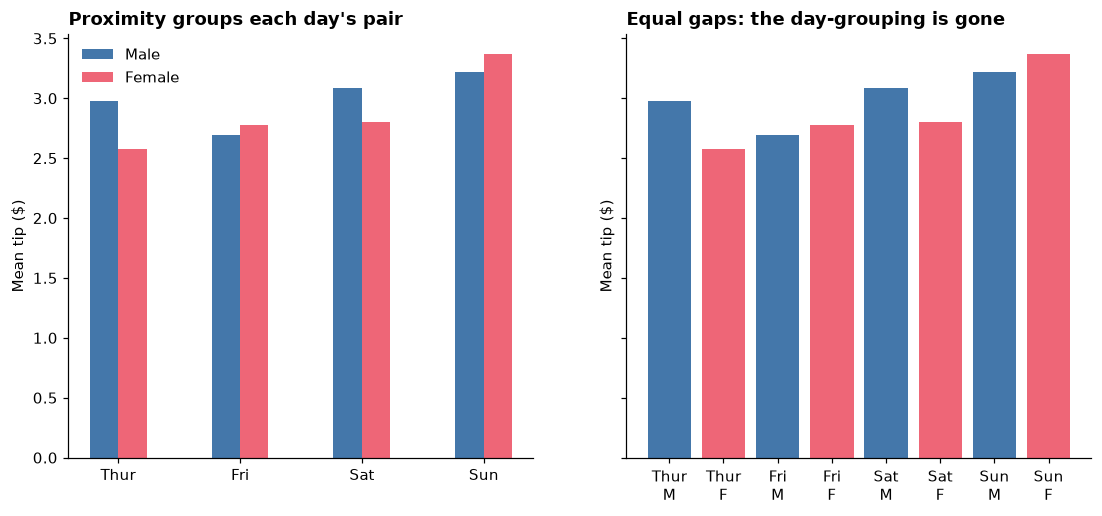

In [5]:
tips = pd.read_csv("data/tips.csv")
days = ["Thur", "Fri", "Sat", "Sun"]
piv = tips.groupby(["day", "sex"])["tip"].mean().unstack().reindex(days)
male, female = piv["Male"].values, piv["Female"].values
C_M, C_F = "#4477aa", "#ee6677"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# proximity version: within-day gap small, between-day gap large
centres = np.array([0, 1.2, 2.4, 3.6])
w = 0.28
axes[0].bar(centres - w/2, male, w, color=C_M, label="Male")
axes[0].bar(centres + w/2, female, w, color=C_F, label="Female")
axes[0].set_xticks(centres); axes[0].set_xticklabels(days)
axes[0].set_title("Proximity groups each day's pair", loc="left", fontweight="bold")
axes[0].legend(frameon=False)

# equal-gap version: every bar equally spaced, day grouping destroyed
xs = np.arange(8)
cols = [C_M, C_F] * 4
axes[1].bar(xs, [v for pair in zip(male, female) for v in pair], 0.8, color=cols)
axes[1].set_xticks(xs)
axes[1].set_xticklabels([f"{d}\n{s}" for d in days for s in ("M", "F")])
axes[1].set_title("Equal gaps: the day-grouping is gone", loc="left", fontweight="bold")

for ax in axes:
    ax.set_ylabel("Mean tip ($)")
    ax.set_ylim(0, None)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.savefig("proximity_tips.png", bbox_inches="tight")
plt.show()

**What the reader loses in the equal-gap version.** With equal spacing the eight bars
read as **eight independent values**; the reader must go to the tick labels to
reconstruct which two bars share a day — working-memory work that the left chart did for
free. Same numbers, strictly more cognitive load. **Attribute/principle named:** left
chart uses **proximity** (spatial grouping, a position attribute) to pre-chunk the data
from eight items into four pairs.

## 5. Where each principle already lives in a chart

- **Proximity** — small multiples: panels sit in a tight grid so each is read as one of
  a family, with white space marking the breaks.
- **Similarity** — a colour legend: every series shares one hue, so matching marks are
  read as one line even when they are scattered across the plot.
- **Enclosure** — a shaded recession band or a boxed annotation: the fill says
  "everything inside here is one region" without a single word.
- **Closure** — an axis frame drawn on only two sides: the eye completes the implied
  rectangle, so the plot still reads as bounded.
- **Continuity** — a line chart's line: the eye follows the smooth trajectory and reads
  the points as one connected trend rather than separate dots.
- **Connection** — a slopegraph: the line joining a category's two time points binds
  them into one unit, which is why a slopegraph beats two separate bar charts.

**The question — legend vs direct labelling, in terms of load.** A legend relies on
**similarity**: the reader must hold a colour in working memory, carry it across the
chart, and match it to each mark — a repeated decode that burns a working-memory slot.
**Direct labelling** puts the name on the line itself and relies on **proximity**: the
label *is* adjacent to its data, so there is nothing to remember and nothing to match.
Proximity resolves at the point of fixation; similarity requires a round trip to the
legend and back. Direct labelling is cheaper because it removes the carry-and-match
step entirely.